---
title: "RBIG warm-start for coupling flows"
short_title: "03 · Coupling warm-start"
subtitle: "fit_rbig_coupling warm-starts a coupling flow via the zero-kernel contract — each coupling begins as a diagonal RBIG marginal, then training switches on the conditioner"
description: >
  Coupling flows are expressive but hard to train from scratch — the conditioner
  starts random, so the coupling transform is random. fit_rbig_coupling warm-starts
  them with an elegant trick: every conditioner's final layer is initialised to a
  zero kernel, so at init each coupling behaves as the diagonal RBIG marginal.
  Training then drives those kernels non-zero, switching on cross-coordinate
  modulation. This notebook shows the warm-start, verifies the zero-kernel
  contract, and watches training break the equivalence.
---

(sec-nb-para-03)=
# 03 — RBIG warm-start for coupling flows

[Notebook 01](01_rbig_warmstart.ipynb) warm-started a *diagonal* flow from a greedy
RBIG fit. Coupling flows ([notebook 02](02_diagonal_vs_coupling.ipynb)) are more
expressive, but that expressiveness makes them *harder* to train from a random
start: the conditioner MLP begins random, so each coupling transform is a random
function of the other coordinates — the optimiser first has to discover that the
conditioner should be doing anything sensible at all.

`gauss_flows.fit_rbig_coupling` warm-starts a coupling flow too, and it does so
with a beautiful trick — the **zero-kernel contract** (the data-dependent /
zero-init idea of Glow {cite}`kingma2018glow`). Right after the greedy fit,
every coupling's conditioner has a **zero final-layer kernel**, so it ignores its
input and emits only its bias. A coupling whose conditioner outputs a *constant*
is exactly a **diagonal marginal** (the RBIG fit of notebook 01) on its active
half. So the warm-started coupling flow *starts life as a diagonal RBIG flow*, and
gradient training switches on the conditioner from there — the
coupling↔diagonal equivalence made concrete.

**What you will see**

- `fit_rbig_coupling` warm-start vs a matched random-init coupling flow.
- The **zero-kernel contract** verified: conditioner kernels are exactly $0$ at
  init, non-zero after training.
- **Cold vs warm** training at an equal budget — the warm start is ahead the whole
  way and lands at a better optimum.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.bijections import Chain, Flip, Invert
from flowjax.distributions import Normal, Transformed
from sklearn.datasets import make_moons

import gauss_flows as gf
from gauss_flows import MixtureGaussianCDFCoupling
from gauss_flows._src.transforms.bijections.coupling.mixture_cdf import (
    MixtureGaussianCDFCoupling as _CouplingClass,
)
from gauss_flows._src.transforms.bijections.linear.rotation import HouseholderRotation
from _style import SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

X, _ = make_moons(n_samples=3000, noise=0.06, random_state=0)
X = jnp.asarray((X - X.mean(0)) / X.std(0))

N_BLOCKS, N_COMPONENTS, NN_WIDTH, NN_DEPTH = 4, 8, 64, 2


def train_flow(flow, *, steps, peak_lr, clip_norm=1.0, batch=512, seed=1):
    """NLL training: optax with gradient clipping + one-cycle cosine LR."""
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    schedule = optax.cosine_onecycle_schedule(transition_steps=steps, peak_value=peak_lr)
    opt = optax.chain(optax.clip_by_global_norm(clip_norm), optax.adam(schedule))
    state = opt.init(params)

    @eqx.filter_jit
    def step(params, state, xb):
        loss, grads = eqx.filter_value_and_grad(
            lambda p: -jnp.mean(jax.vmap(eqx.combine(p, static).log_prob)(xb)))(params)
        updates, state = opt.update(grads, state)
        return eqx.apply_updates(params, updates), state, loss

    key, traj = jr.key(seed), []
    for i in range(steps):
        key, sk = jr.split(key)
        idx = jr.randint(sk, (batch,), 0, X.shape[0])
        params, state, loss = step(params, state, X[idx])
        if i % 25 == 0:
            traj.append(float(loss))
    return eqx.combine(params, static), np.array(traj)


logp = lambda flow: float(jax.vmap(flow.log_prob)(X).mean())

## 1. Warm-start vs random-init coupling

`fit_rbig_coupling` greedily fits a **mixture-CDF** coupling flow. For a fair
comparison we build a random-init flow with the *same* architecture (the public
`coupling_gaussianization_flow` uses spline couplings, so we assemble the matching
mixture-CDF stack directly). Both are `Invert`-wrapped `Chain`s of
rotation + coupling blocks.

In [2]:
def random_coupling_flow(key, n_blocks, n_components):
    """A random-init mixture-CDF coupling flow matching fit_rbig_coupling's stack."""
    bijections = []
    for k in jr.split(key, n_blocks):
        rk, ck1, ck2 = jr.split(k, 3)
        rot = HouseholderRotation(n_reflections=2, shape=(2,))
        rot = eqx.tree_at(lambda r: r.params, rot, jr.normal(rk, rot.params.shape))
        coupling_kw = dict(shape=(2,), n_components=n_components,
                           nn_width=NN_WIDTH, nn_depth=NN_DEPTH)
        bijections += [rot,
                       MixtureGaussianCDFCoupling(ck1, **coupling_kw),
                       Flip(shape=(2,)),
                       MixtureGaussianCDFCoupling(ck2, **coupling_kw),
                       Flip(shape=(2,))]
    return Transformed(Normal(jnp.zeros(2)), Invert(Chain(bijections)))


cold_init = random_coupling_flow(jr.key(3), N_BLOCKS, N_COMPONENTS)
warm_init = gf.fit_rbig_coupling(X, jr.key(3), n_layers=N_BLOCKS, n_components=N_COMPONENTS,
                                 nn_width=NN_WIDTH, nn_depth=NN_DEPTH)

print(f"coupling log p at init:  random = {logp(cold_init):+.3f}   "
      f"RBIG warm = {logp(warm_init):+.3f}  (improvement {logp(warm_init) - logp(cold_init):+.3f})")

coupling log p at init:  random = -4.329   RBIG warm = -1.924  (improvement +2.406)


The warm start already sits near a good fit ($\approx -1.9$ nats) with no gradient
steps, while the random coupling is far worse — its random conditioner scrambles
the transform. How does RBIG achieve a good coupling init? The answer is the next
section.

## 2. The zero-kernel contract

A coupling layer transforms its active half with parameters predicted by a
conditioner MLP from the *other* half. If that MLP's **final-layer kernel is
zero**, it outputs only its bias — a *constant*, independent of the input — and a
coupling with constant parameters is just a **diagonal marginal transform**.
`fit_rbig_coupling` exploits this: it sets every conditioner's final kernel to
zero and fits the bias to RBIG's per-dimension GMM. So at init the coupling flow
*is* the diagonal RBIG flow. We read the kernels straight off the modules.

In [3]:
def max_final_kernels(flow):
    """max|W| of every coupling conditioner's final Dense layer."""
    return [float(jnp.max(jnp.abs(b._coupling.conditioner.layers[-1].weight)))
            for b in flow.bijection.bijection.bijections
            if isinstance(b, _CouplingClass)]

k_warm = max_final_kernels(warm_init)
k_cold = max_final_kernels(cold_init)
print(f"max|final kernel| per coupling, RBIG warm init: {[f'{k:.1e}' for k in k_warm]}")
print(f"  -> all exactly zero: {all(k == 0.0 for k in k_warm)}  (conditioner = constant = diagonal marginal)")
print(f"max|final kernel| per coupling, random init   : {[f'{k:.2f}' for k in k_cold]}")

max|final kernel| per coupling, RBIG warm init: ['0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00']
  -> all exactly zero: True  (conditioner = constant = diagonal marginal)
max|final kernel| per coupling, random init   : ['0.12', '0.12', '0.12', '0.12', '0.12', '0.12', '0.12', '0.12']


Every warm-init kernel is **exactly zero** — the conditioner is switched off, so
each coupling acts as a diagonal RBIG marginal (this is the *coupling ↔ diagonal
equivalence* in action). The random flow's kernels are non-zero noise. Training
now has a sensible place to start *and* the freedom to turn the conditioners on.

## 3. Training breaks the equivalence

We train both for the **same budget** (3000 steps), the warm start with a
moderate LR ($10^{-3}$, it begins near a good optimum) and the random flow with a
larger one ($3\times10^{-3}$). As gradients flow, the warm flow's conditioner
kernels move **off zero** — the couplings stop being diagonal and start modelling
cross-coordinate structure.

warm conditioner kernels: init ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00'] -> trained ['0.17', '0.14', '0.17', '0.23', '0.60', '0.15', '0.32', '0.22']  (switched on)

mean log p(x) after 3000 steps each:
  random init : -1.275


  RBIG warm   : -1.203   <- better optimum, and ahead the whole way


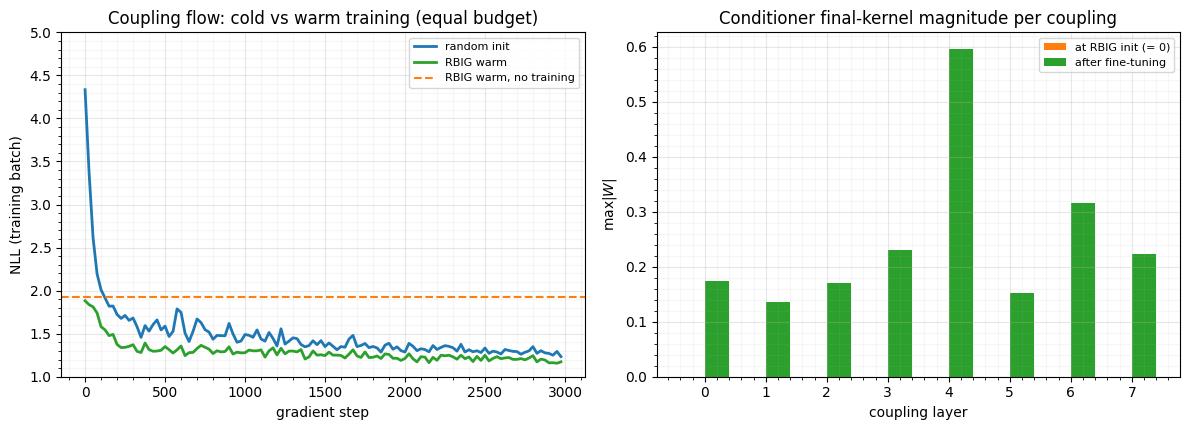

In [4]:
STEPS = 3000
cold, traj_cold = train_flow(cold_init, steps=STEPS, peak_lr=3e-3)
warm, traj_warm = train_flow(warm_init, steps=STEPS, peak_lr=1e-3)

k_warm_trained = max_final_kernels(warm)
print(f"warm conditioner kernels: init {[f'{k:.2f}' for k in k_warm]} "
      f"-> trained {[f'{k:.2f}' for k in k_warm_trained]}  (switched on)")
print(f"\nmean log p(x) after {STEPS} steps each:")
print(f"  random init : {logp(cold):+.3f}")
print(f"  RBIG warm   : {logp(warm):+.3f}   <- better optimum, and ahead the whole way")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4))
axL.plot(np.arange(len(traj_cold)) * 25, traj_cold, color="tab:blue", lw=2, label="random init")
axL.plot(np.arange(len(traj_warm)) * 25, traj_warm, color="tab:green", lw=2, label="RBIG warm")
axL.axhline(-logp(warm_init), color="tab:orange", lw=1.5, ls="--", label="RBIG warm, no training")
axL.set(title="Coupling flow: cold vs warm training (equal budget)", xlabel="gradient step",
        ylabel="NLL (training batch)", ylim=(1.0, 5.0))
axL.legend(fontsize=8); style_ax(axL)

xb = np.arange(len(k_warm))
axR.bar(xb - 0.2, k_warm, 0.4, color="tab:orange", label="at RBIG init (= 0)")
axR.bar(xb + 0.2, k_warm_trained, 0.4, color="tab:green", label="after fine-tuning")
axR.set(title="Conditioner final-kernel magnitude per coupling",
        xlabel="coupling layer", ylabel=r"$\max|W|$")
axR.legend(fontsize=8); style_ax(axR)
fig.tight_layout()

At an equal budget the warm flow is ahead the entire way — it opens near the
random flow's *final* loss and settles at a **better** optimum — and the bar chart
tells the mechanistic story: the conditioner kernels lift off zero during training
(right). The flow transitions from "diagonal RBIG marginal" to "true coupling"
exactly as the kernels switch on. (The expressive coupling flow *can* reach a good
fit from a random start too, but it needs more steps and lands slightly worse here
— warm-start buys both speed and a better optimum, as it did for the diagonal flow
in notebook 01.)

## 4. The learned densities

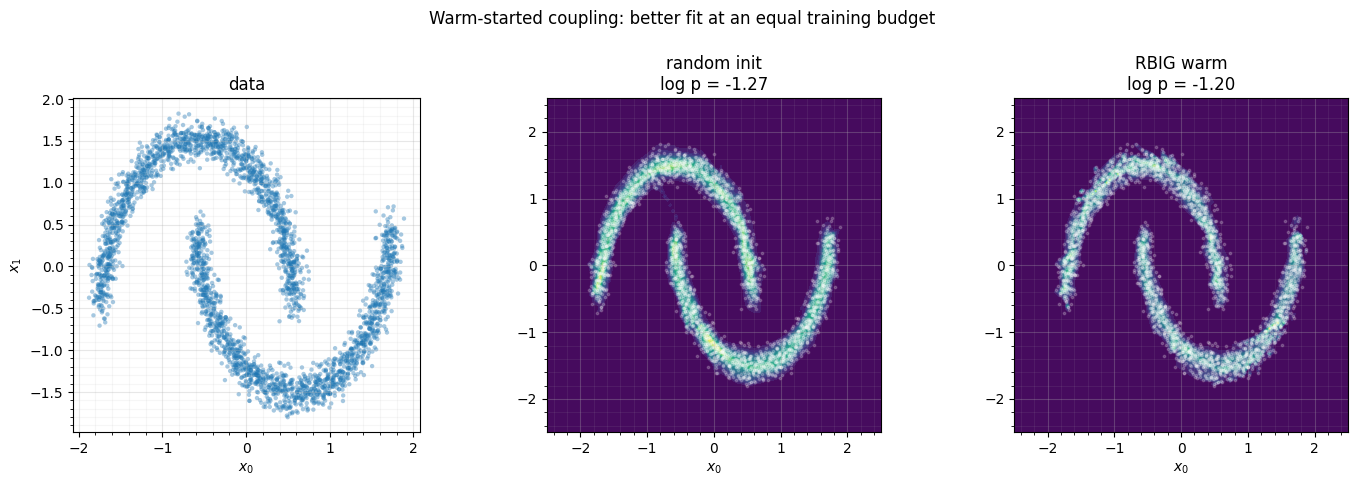

In [5]:
gx, gy = np.meshgrid(np.linspace(-2.5, 2.5, 120), np.linspace(-2.5, 2.5, 120))
grid = jnp.asarray(np.column_stack([gx.ravel(), gy.ravel()]))
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6))
axes[0].scatter(X[:, 0], X[:, 1], color="tab:blue", **SCATTER_KW)
axes[0].set(title="data", xlabel="$x_0$", ylabel="$x_1$")
for ax, model, t in [(axes[1], cold, "random init"),
                     (axes[2], warm, "RBIG warm")]:
    lp = np.asarray(jax.vmap(model.log_prob)(grid)).reshape(gx.shape)
    ax.contourf(gx, gy, np.exp(lp), levels=18, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], s=3, color="white", alpha=0.2)
    ax.set(title=f"{t}\nlog p = {logp(model):.2f}", xlabel="$x_0$")
for ax in axes:
    ax.set_aspect("equal"); style_ax(ax)
fig.suptitle("Warm-started coupling: better fit at an equal training budget", y=1.02)
fig.tight_layout()

## Recap

| start | init log p | conditioner kernel | training (3000 steps) | final log p |
|---|---|---|---|---|
| random coupling | $-4.3$ | random noise | lr $3\times10^{-3}$ | $\approx -1.28$ |
| **RBIG warm** | $-1.9$ | **exactly 0** (= diagonal) | lr $10^{-3}$ | $\approx -1.20$ (better) |

- `fit_rbig_coupling` warm-starts a coupling flow by the **zero-kernel contract**:
  conditioners emit constants, so each coupling *is* a diagonal RBIG marginal at
  init.
- Gradient training drives the kernels off zero — the couplings switch from
  diagonal to genuinely conditional, the coupling↔diagonal equivalence breaking as
  it trains.
- At an **equal training budget** the warm start is ahead the whole way and lands
  at a better optimum — buying both speed and quality, as it did for the diagonal
  flow in notebook 01. (Coupling is the more expensive architecture, so it wants a
  real training budget — a few thousand steps — to converge.)

**Next up.** We have trained and warm-started several flows but treated each as a
black box. [04 — Layer-wise inspection](04_layerwise_inspection.ipynb) opens one
up — pushing data through one layer at a time to watch Gaussianity improve and
diagnose *where* in the stack the work happens.